In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

## step 3: data cleaning and preprocessing

In [3]:
# read the file
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Data science project datasets\house predcton dataset.csv")
print(df.shape)
print(df.describe)
print(df.head())
print(df.dtypes)

# drop columns that are not necessary 
print(df.drop(columns=['date','street','country'], inplace = True))

# handle missing values zero values annomalies
print(df[df['price']>0])

# convert state zip to categorical data type
df['statezip'] = df['statezip'].astype("category")

# check the remaining columns
print(df.columns)

(4600, 18)
<bound method NDFrame.describe of                      date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterf

 ## Observation step 1
 We dropped date, street and country because they introduce noise as the country column is constant and street is too unique for the set


## Step 4: Exploratory Data Analysis

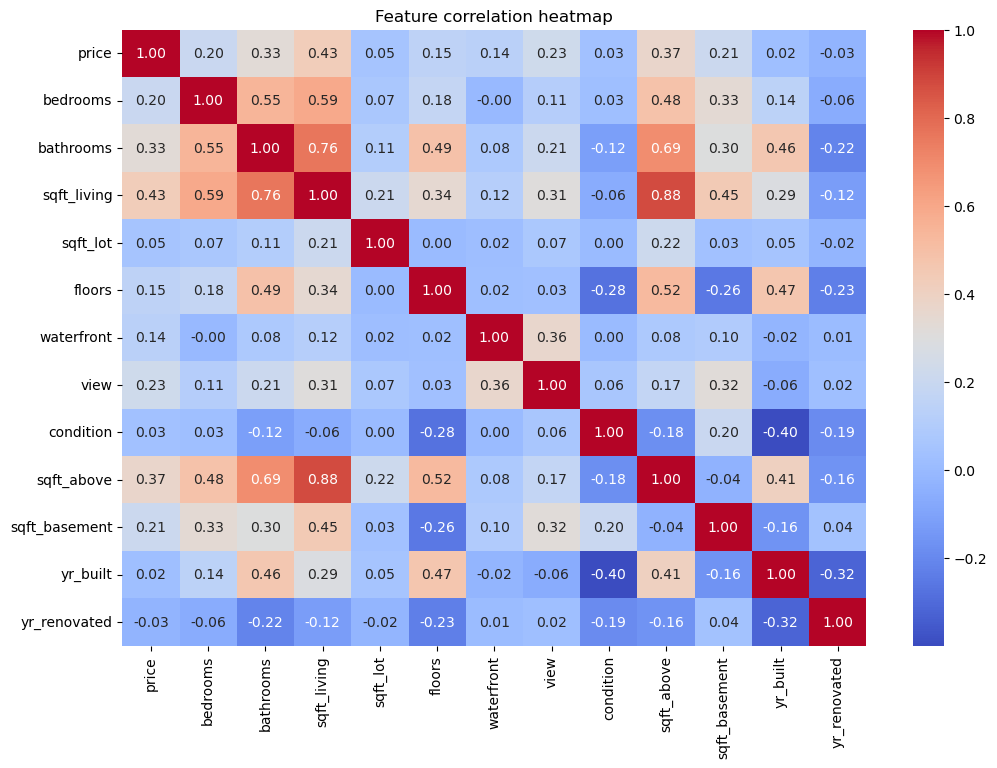

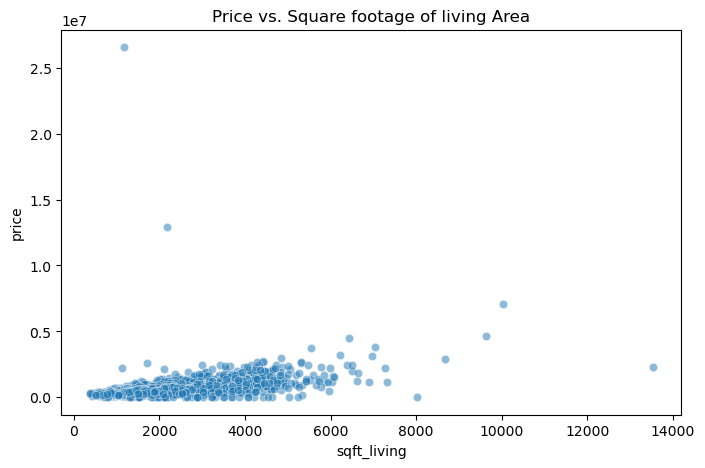

In [4]:
# a correlation heatmap for the numerical numbers
plt.figure(figsize= (12, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns. heatmap(corr,annot = True, cmap = "coolwarm", fmt=".2f")
plt.title("Feature correlation heatmap")
plt.show()



# scatter plot for sqft_living  vs price
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'sqft_living', y= 'price', alpha = 0.5)
plt.title("Price vs. Square footage of living Area")
plt.show()

# A HISTOGRAM TO SHOW THE SKEWNESS


## Feature Engineering
An algorithm understands numbers better than raw years. Converting yr_built to house_age provides a continuous scale. Since yr_renovated contains many zeros, converting it to a binary is_renovated feature captures the impact of a renovation perfectly. We one-hot encoded the city because location heavily dictates real estate prices.

In [8]:
# 1. create a house age feature
current_year = 2014 # based on the datasets
df['house_age'] =  current_year - df['yr_built']

# 2. Create a binary was Renovated feature
df['is_renovated'] = df['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)

# 3. drop the old year columns to reduce multicollinearity
df =df.drop(columns = ['yr_built', 'yr_renovated'])

#encode city to categorical processing
df = pd.get_dummies(df, columns = ['city'],drop_first = True)

# separate feature x and y target
X = df.drop(columns=['price'])
y = df['price']


KeyError: 'yr_built'

## 6. Model building
we split the data to ensure we test the model on unseen data, preventing overfitting. Standard Scaling ensures all numerical features contribute equally

In [ ]:
# split data: 80% training and 20% testing
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# scale numerical feature for good distance-based algorithms 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#initialize and train the model
model = RandomForestRegressor(n_estimators = 100, random_state = 42)
model.fit(X_train_scaled, y_train)

# Generate prediction
y_pred = model.predict(X_test_scaled)
